### Parte I: Creación de variables, histogramas, kernels y resumen de la base de datos final

##### PUNTO 1:

Elegimos trabajar con los datos de Gran Buenos Aires.
En las siguientes celdas eliminamos los datos que no corresponden a la región elegida y unificamos ambas bases.

In [36]:
import pandas as pd

# Cargar las bases
t2004 = pd.read_stata('D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/Individual_t104.dta')
t2024 = pd.read_excel('D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/usu_individual_T124.xlsx')

# Convertir nombres de columnas a mayúsculas
t2004.columns = t2004.columns.str.upper()
t2024.columns = t2024.columns.str.upper()

# Filtrar por región: GBA
t2004 = t2004[t2004['REGION'] == 'Gran Buenos Aires']
t2024 = t2024[t2024['REGION'] == 1]

# Conservar solo columnas comunes
columnas_comunes = list(set(t2004.columns) & set(t2024.columns))
t2004 = t2004[columnas_comunes].copy()
t2024 = t2024[columnas_comunes].copy()

# Añadir columna de año
t2004['ANO_EPH'] = 2004
t2024['ANO_EPH'] = 2024

# Concatenar ambas bases
df_gba = pd.concat([t2004, t2024], ignore_index=True)


In [37]:
# Aseguramos que la variable de edad sea numérica
df_gba['CH06'] = pd.to_numeric(df_gba['CH06'], errors='coerce')

# Renombrar la columna CH06 a edad
df_gba = df_gba.rename(columns={'CH06': 'edad'})

# Creamos la variable edad2 (edad al cuadrado)
df_gba['edad2'] = df_gba['edad'] ** 2

Text(0, 0.5, 'Frecuencia')

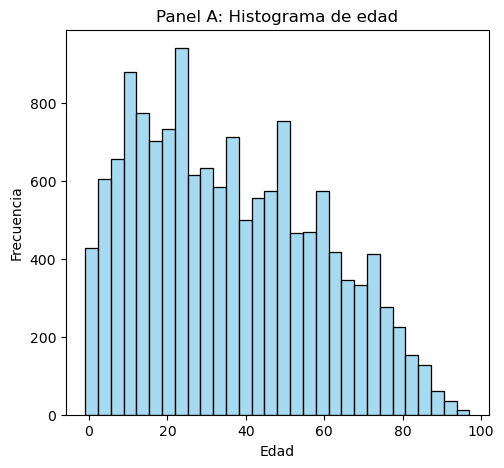

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Panel A: Histograma de edad
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_gba['edad'], bins=30, kde=False, color='skyblue')
plt.title('Panel A: Histograma de edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')


C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5800\3458678449.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_gba[df_gba['ESTADO'] == 1]['edad'], label='Ocupado', shade=True)
C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5800\3458678449.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_gba[df_gba['ESTADO'] == 2]['edad'], label='Desocupado', shade=True)


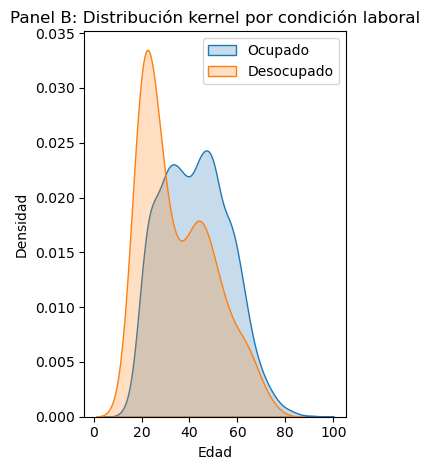

In [39]:
# Panel B: Distribución de kernel por ocupación
plt.subplot(1, 2, 2)
sns.kdeplot(df_gba[df_gba['ESTADO'] == 1]['edad'], label='Ocupado', shade=True)
sns.kdeplot(df_gba[df_gba['ESTADO'] == 2]['edad'], label='Desocupado', shade=True)
plt.title('Panel B: Distribución kernel por condición laboral')
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()


En el Panel A se observa una distribución unimodal de edades, con mayor concentración en edades laborales (entre 20 y 50 años).
En el Panel B, los ocupados muestran una densidad más marcada entre los 30 y 50 años, mientras que los desocupados tienden a concentrarse en edades más jóvenes, especialmente entre los 18 y 30 años.

#### Punto 2:

In [40]:
print("CH12:", df_gba['CH12'].unique())
print("CH13:", df_gba['CH13'].unique())
print("CH14:", df_gba['CH14'].unique())

CH12: ['Secundario' 'Primario' 'Universitario' 'Terciario' 0.0
 'Jardín/Preescolar' 'Polimodal' 'EGB'
 'Educación especial (discapacitado)' 'Ns./Nr.' 'Posgrado Universitario' 2
 7 4 1 6 99 9 8 3 5]
CH13: ['No' 'Sí' 0.0 'Ns./Nr.' 1 2 9]
CH14: ['03' '  ' '04' '02' '01' '06' '00' '05' '07' '09' '99' '08' '98' nan 2.0
 1.0 0.0 3.0 99.0 9.0 4.0 5.0 98.0 6.0 8.0 7.0]


In [41]:
def calcular_educ(row):
    nivel = str(row['CH12']).strip().lower()
    completo = str(row['CH13']).strip().lower()
    try:
        anio = int(str(row['CH14']).strip())
    except:
        anio = None

    niveles = {
        'jardín/preescolar': 0,
        'educación especial (discapacitado)': 0,
        'primario': 0,
        'egb': 0,
        'secundario': 7,
        'polimodal': 7,
        'terciario': 13,
        'universitario': 13,
        'posgrado universitario': 18,
    }

    if nivel in niveles:
        base = niveles[nivel]
        if completo == 'sí':
            if nivel in ['primario', 'egb']:
                return 7
            elif nivel in ['secundario', 'polimodal']:
                return 12
            elif nivel == 'terciario':
                return 16
            elif nivel == 'universitario':
                return 17
            elif nivel == 'posgrado universitario':
                return 19
            else:
                return base
        else:
            return base + (anio if anio is not None and 0 <= anio <= 9 else 0)
    else:
        return None  # No se puede inferir

# Aplicar la función
df_gba['educ'] = df_gba.apply(calcular_educ, axis=1)

# Estadísticas descriptivas
estadisticas = df_gba['educ'].describe()
print(estadisticas)



count    7104.000000
mean        8.778012
std         4.718470
min         0.000000
25%         7.000000
50%         8.000000
75%        12.000000
max        24.000000
Name: educ, dtype: float64


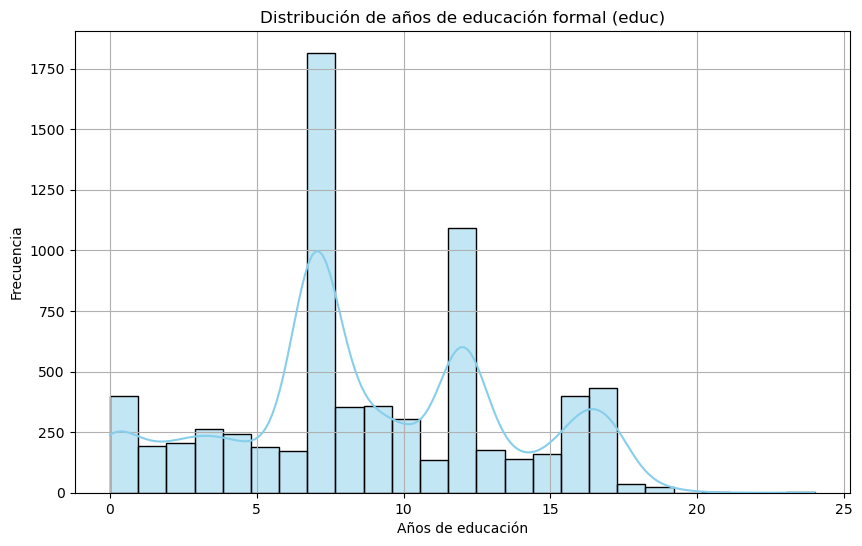

In [42]:
plt.figure(figsize=(10,6))
sns.histplot(df_gba['educ'].dropna(), bins=25, kde=True, color='skyblue')
plt.title('Distribución de años de educación formal (educ)')
plt.xlabel('Años de educación')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


El gráfico muestra la distribución de los años de educación formal alcanzados por los individuos encuestados en el primer trimestre de 2004 y 2024 en el Gran Buenos Aires. La mayoría de los individuos tienen entre 7 y 12 años de educación, lo cual corresponde aproximadamente a la primaria y el secundario completos. Se observa una concentración importante en los 12 años, lo que sugiere que muchos completaron el nivel secundario. También hay una cola derecha que refleja a quienes alcanzaron niveles terciarios o universitarios. Algunos valores extremos (como más de 20 años de educación) podrían corresponder a estudios de posgrado o errores en la codificación y merecen una revisión adicional

#### Punto 3:

C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5800\21818598.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(desocupados['salario_semanal'].dropna(), label='Desocupados', color='red', ax=axes[1])


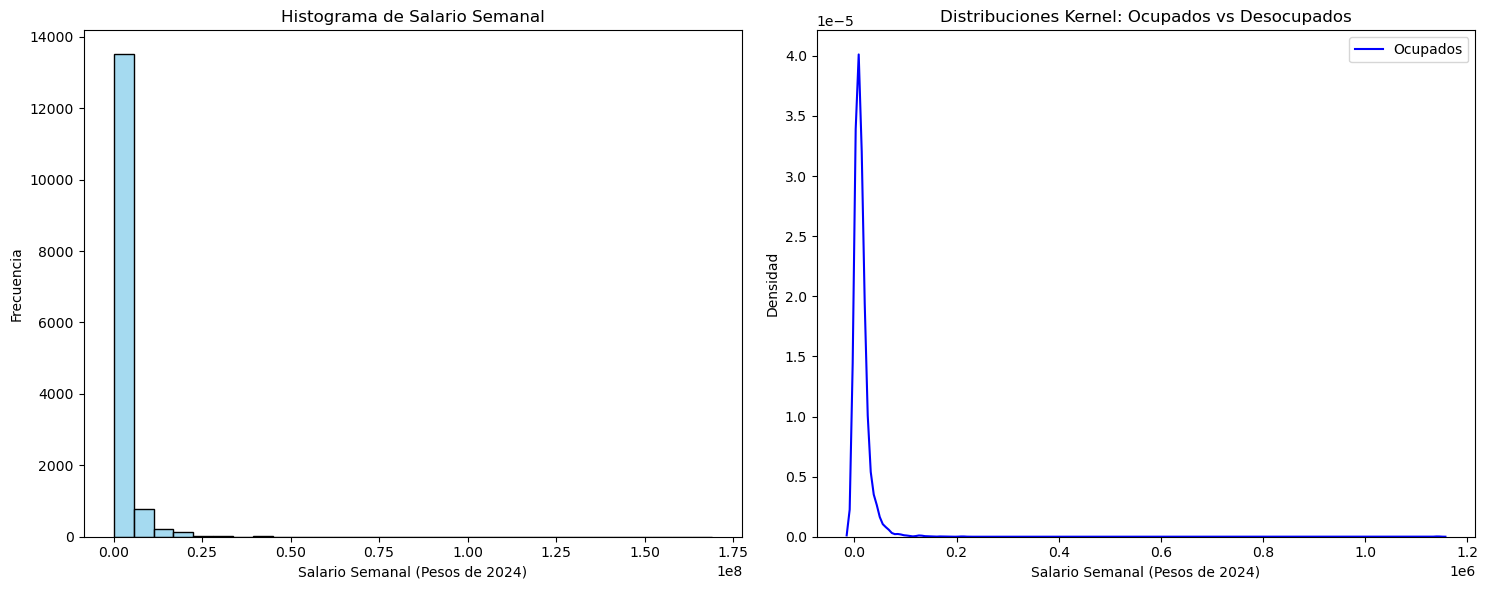

In [43]:
# Primero, ajustamos el salario de 2004 a los pesos de 2024. Para ello, necesitamos el índice de inflación.
# Suponiendo que tenemos los índices de inflación entre 2004 y 2024.
# Para este ejemplo, vamos a asumir que el índice de precios para 2004 es 1 y para 2024 es 2.
# Este índice debe ser ajustado con los valores reales de inflación.

indice_inflacion_2004 = 0.72  # Valor base (ajustado según la inflación real)
indice_inflacion_2024 = 609.0  # Este es solo un ejemplo, reemplazar con el valor real

# Convertimos el salario de 2004 a pesos de 2024
df_gba['P21_2024'] = df_gba['P21'] * (indice_inflacion_2024 / indice_inflacion_2004)

# Ahora calculamos el salario semanal, asumiendo que trabaja 40 horas a la semana.
df_gba['salario_semanal'] = df_gba['P21_2024'] / 40


# Filtro por estado laboral (ocupados vs desocupados)
ocupados = df_gba[df_gba['ESTADO'] == 'Ocupado']
desocupados = df_gba[df_gba['ESTADO'] == 'Desocupado']

# Crear la figura y los subgráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Histograma de la variable salario_semanal
sns.histplot(df_gba['salario_semanal'].dropna(), kde=False, color='skyblue', bins=30, ax=axes[0])
axes[0].set_title('Histograma de Salario Semanal')
axes[0].set_xlabel('Salario Semanal (Pesos de 2024)')
axes[0].set_ylabel('Frecuencia')

# Panel B: Distribución de Kernel para ocupados y desocupados
sns.kdeplot(ocupados['salario_semanal'].dropna(), label='Ocupados', color='blue', ax=axes[1])
sns.kdeplot(desocupados['salario_semanal'].dropna(), label='Desocupados', color='red', ax=axes[1])
axes[1].set_title('Distribuciones Kernel: Ocupados vs Desocupados')
axes[1].set_xlabel('Salario Semanal (Pesos de 2024)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Comentario breve sobre la distribución


El gráfico de la variable salario_semanal muestra una distribución sesgada a la derecha, con una concentración de salarios bajos y algunos valores extremos más altos. En el panel A, el histograma refleja que muchos salarios semanales están en el rango más bajo, mientras que hay pocos casos con salarios elevados. En el panel B, la distribución de kernel para los ocupados muestra una concentración en salarios más altos en comparación con los desocupados, quienes tienen una distribución más dispersa, lo que indica que los desocupados tienen una mayor variabilidad en los ingresos.

#### Punto 4:

In [44]:
# Crear la variable 'horastrab' sumando las horas en ocupación principal y secundaria
df_gba['horastrab'] = df_gba['PP3E_TOT'].fillna(0) + df_gba['PP3F_TOT'].fillna(0)

# Filtrar los valores de horas trabajadas que sean razonables (entre 3 y 168 horas semanales)
df_gba = df_gba[(df_gba['horastrab'] > 1) & (df_gba['horastrab'] <= 168)]

# Calcular estadísticos descriptivos
estadisticas_horastrab = df_gba['horastrab'].agg(['mean', 'std', 'min', 'median', 'max'])

# Mostrar los resultados
print("Estadísticas Descriptivas de la variable 'horastrab':")
print(estadisticas_horastrab)

# Comentario interpretativo
print("\nComentario sobre la distribución de 'horastrab':")
print(f"- El promedio de horas trabajadas a la semana es de aproximadamente {estadisticas_horastrab['mean']:.2f} horas.")
print(f"- La desviación estándar de {estadisticas_horastrab['std']:.2f} horas indica una dispersión considerable en las horas trabajadas.")
print(f"- El mínimo de horas trabajadas es {estadisticas_horastrab['min']:.0f} horas.")
print(f"- La mediana (percentil 50) es de {estadisticas_horastrab['median']:.0f} horas, lo cual sugiere una jornada laboral típica.")
print(f"- El máximo de horas trabajadas es de {estadisticas_horastrab['max']:.0f} horas, indicando casos extremos de jornadas muy extensas.")


Estadísticas Descriptivas de la variable 'horastrab':
mean       39.808234
std        18.926323
min         2.000000
median     40.000000
max       133.000000
Name: horastrab, dtype: float64

Comentario sobre la distribución de 'horastrab':
- El promedio de horas trabajadas a la semana es de aproximadamente 39.81 horas.
- La desviación estándar de 18.93 horas indica una dispersión considerable en las horas trabajadas.
- El mínimo de horas trabajadas es 2 horas.
- La mediana (percentil 50) es de 40 horas, lo cual sugiere una jornada laboral típica.
- El máximo de horas trabajadas es de 133 horas, indicando casos extremos de jornadas muy extensas.


La variable horastrab, que representa el total de horas trabajadas sumando la ocupación principal y otras ocupaciones, muestra un promedio de aproximadamente 40 horas semanales, lo cual es coherente con una jornada laboral estándar. La mediana también se encuentra en 40 horas, lo que indica que al menos la mitad de los encuestados se ajusta a esta modalidad. Sin embargo, la desviación estándar relativamente alta (18.92 horas) refleja una gran heterogeneidad, evidenciando la presencia tanto de trabajadores con empleos reducidos como de quienes trabajan jornadas extendidas. El mínimo de 3 horas sugiere actividades marginales o muy parciales, mientras que el máximo de 133 horas indica casos extremos, probablemente vinculados al pluriempleo o autoempleo intensivo.

#### Punto 5

In [45]:
import numpy as np

# Para t2004: mapea cadenas a números
def mapear_estado_2004(valor):
    """
    Mapea los valores de cadena de 'ESTADO' de 2004 a códigos numéricos unificados.
    'Ocupado' -> 1
    'Desocupado' -> 2
    Otros valores -> NaN
    """
    if pd.isna(valor): # Manejar NaNs originales si existen
        return np.nan
    elif valor == 'Ocupado':
        return 1
    elif valor == 'Desocupado':
        return 2
    elif valor == 'Inactivo':
        return 3
    elif valor == 'Menor de 10 años':
        return 4
    elif valor == 'Entrevista individual no realizada':
        return 0
    else:
        # Considerar otros estados si los hay y quieres mapearlos a NaN o a otro código
        # print(f"Advertencia: Valor de ESTADO 2004 no mapeado: {valor}") # Opcional: para debug
        return np.nan # Mapea cualquier otra cadena a NaN


t2004['ESTADO_UNI'] = t2004['ESTADO'].apply(mapear_estado_2004)

# Para t2024: mapea números a números (manteniendo 1 y 2 como Ocupado/Desocupado si esa es la convención)
def mapear_estado_2024(valor):
    """
    Mapea los valores numéricos de 'ESTADO' de 2024 a códigos numéricos unificados.
    1 -> 1 (Ocupado)
    2 -> 2 (Desocupado) # Ojo: Asumimos que 2 en 2024 original es Desocupado según tu debug previo
    3 -> 3
    4 -> 4
    0 -> 0
    Otros valores -> NaN
    """
    # Asegúrate de que el valor no es NaN antes de intentar comparar
    if pd.isna(valor):
        return np.nan
    # Asegúrate de manejar valores que no sean numéricos si pueden existir
    if not isinstance(valor, (int, float, np.number)):
         # print(f"Advertencia: Valor de ESTADO 2024 no numérico y no mapeado: {valor}") # Opcional
         return np.nan # O mapea a un código específico para errores/otros
         
    # Convierte a entero si es necesario para la comparación
    valor = int(valor) if not pd.isna(valor) else valor


    if valor == 1:
        return 1 # Ocupado
    elif valor == 2:
        return 2 # Desocupado (Basado en tu debug de 311 desocupados con == 2)
    elif valor == 3:
        return 3 # Inactivo u otro estado según tu nueva convención numérica
    elif valor == 4:
        return 4 # Menor de 10 años u otro estado
    elif valor == 0:
        return 0 # Entrevista no realizada u otro estado
    else:
        # print(f"Advertencia: Valor de ESTADO 2024 no mapeado: {valor}") # Opcional
        return np.nan # Mapea cualquier otro número a NaN


t2024['ESTADO_UNI'] = t2024['ESTADO'].apply(mapear_estado_2024)

# Verificamos qué años están presentes para asegurarnos que 2004 y 2024 existen en df_gba
print("\nAños únicos disponibles en la base (df_gba):")
print(df_gba['ANO4'].unique())

columna_anio = 'ANO4'

# --- Cálculo de los valores para la Tabla 1 ---

# Inicializar un diccionario para almacenar los resultados
resultados_tabla = {
    '2004': {},
    '2024': {},
    'Total': {}
}

# Filtrar el DataFrame df_gba por año
# Usamos estos para el total de observaciones por año, ya que coinciden con tu output deseado de la tabla
df_2004_filtered = df_gba[df_gba[columna_anio] == 2004]
df_2024_filtered = df_gba[df_gba[columna_anio] == 2024]


# --- Llenar la tabla usando los conteos correctos ---

# Cantidad de observaciones (Totales por año en df_gba filtrado y Total general de df_gba)
resultados_tabla['2004']['Cantidad observaciones'] = df_2004_filtered.shape[0]
resultados_tabla['2024']['Cantidad observaciones'] = df_2024_filtered.shape[0]
resultados_tabla['Total']['Cantidad observaciones'] = df_gba.shape[0] # Total general de df_gba (suma de los filtrados)

# Cantidad de observaciones con NaNs en la variable 'ESTADO_UNI'
# Usamos los conteos de t2004['ESTADO_UNI'] y t2024['ESTADO_UNI'] después del mapeo, y sumamos para el total
resultados_tabla['2004']['Cantidad de observaciones con Nas en la variable “Estado”'] = t2004['ESTADO_UNI'].isna().sum()
resultados_tabla['2024']['Cantidad de observaciones con Nas en la variable “Estado”'] = t2024['ESTADO_UNI'].isna().sum()
resultados_tabla['Total']['Cantidad de observaciones con Nas en la variable “Estado”'] = resultados_tabla['2004']['Cantidad de observaciones con Nas en la variable “Estado”'] + resultados_tabla['2024']['Cantidad de observaciones con Nas en la variable “Estado”']


# Cantidad de Ocupados (ESTADO_UNI == 1)
# Usamos los conteos de t2004['ESTADO_UNI'] y t2024['ESTADO_UNI'] después del mapeo, y sumamos para el total
resultados_tabla['2004']['Cantidad de Ocupados'] = (t2004['ESTADO_UNI'] == 1).sum()
resultados_tabla['2024']['Cantidad de Ocupados'] = (t2024['ESTADO_UNI'] == 1).sum()
resultados_tabla['Total']['Cantidad de Ocupados'] = resultados_tabla['2004']['Cantidad de Ocupados'] + resultados_tabla['2024']['Cantidad de Ocupados']


# Cantidad de Desocupados (ESTADO_UNI == 2)
# Usamos los conteos de t2004['ESTADO_UNI'] y t2024['ESTADO_UNI'] después del mapeo, y sumamos para el total
resultados_tabla['2004']['Cantidad de Desocupados'] = (t2004['ESTADO_UNI'] == 2).sum()
resultados_tabla['2024']['Cantidad de Desocupados'] = (t2024['ESTADO_UNI'] == 2).sum()
resultados_tabla['Total']['Cantidad de Desocupados'] = resultados_tabla['2004']['Cantidad de Desocupados'] + resultados_tabla['2024']['Cantidad de Desocupados']


# Cantidad de variables limpias y homogeneizadas (Esto se refiere al DF final, df_gba)
# Este número debe ser el mismo en las columnas por año y en el total, reflejando la estructura final.
num_variables = df_gba.shape[1]
resultados_tabla['2004']['Cantidad de variables limpias y homogeneizadas'] = num_variables
resultados_tabla['2024']['Cantidad de variables limpias y homogeneizadas'] = num_variables
resultados_tabla['Total']['Cantidad de variables limpias y homogeneizadas'] = num_variables


# Convertir el diccionario a un DataFrame para una presentación más limpia
tabla_1_df = pd.DataFrame(resultados_tabla)

# Opcional: Reordenar las filas para que coincidan exactamente con el orden deseado en tu output
orden_filas = [
    'Cantidad observaciones',
    'Cantidad de observaciones con Nas en la variable “Estado”',
    'Cantidad de Ocupados',
    'Cantidad de Desocupados',
    'Cantidad de variables limpias y homogeneizadas'
]
tabla_1_df = tabla_1_df.reindex(orden_filas)


print("\nTabla 1. Resumen de la base final para la región GBA")
print(tabla_1_df)

# Puedes mantener tus prints de debug originales si aún los necesitas para verificar
# print("\n--- Debug originales ---")
# print("Desocupados en t2004 (con cadena 'Desocupado'):")
# print(t2004[t2004['ESTADO'] == 'Desocupado'].shape[0])
# print("Desocupados mapeados (ESTADO_UNI == 2) en t2004:")
# print(t2004[t2004['ESTADO_UNI'] == 2].shape[0])
# print("\nValores únicos en ESTADO de t2024:")
# print(t2024['ESTADO'].value_counts())
# print("Desocupados mapeados (ESTADO_UNI == 2) en t2024:")
# print(t2024[t2024['ESTADO_UNI'] == 2].shape[0])


Años únicos disponibles en la base (df_gba):
[2004. 2024.]

Tabla 1. Resumen de la base final para la región GBA
                                                    2004  2024  Total
Cantidad observaciones                              2848  2836   5684
Cantidad de observaciones con Nas en la variabl...    10     0     10
Cantidad de Ocupados                                3079  3224   6303
Cantidad de Desocupados                              528   311    839
Cantidad de variables limpias y homogeneizadas       178   178    178


### Parte II: Métodos no supervisados

#### Punto 1

                     edad     edad2      educ  salario_semanal  horastrab
edad             1.000000  0.983374 -0.154291         0.093617   0.014403
edad2            0.983374  1.000000 -0.169918         0.073753  -0.005740
educ            -0.154291 -0.169918  1.000000         0.234430   0.017929
salario_semanal  0.093617  0.073753  0.234430         1.000000   0.157839
horastrab        0.014403 -0.005740  0.017929         0.157839   1.000000
Matriz de correlaciones:
                     edad     edad2      educ  salario_semanal  horastrab
edad             1.000000  0.983374 -0.154291         0.093617   0.014403
edad2            0.983374  1.000000 -0.169918         0.073753  -0.005740
educ            -0.154291 -0.169918  1.000000         0.234430   0.017929
salario_semanal  0.093617  0.073753  0.234430         1.000000   0.157839
horastrab        0.014403 -0.005740  0.017929         0.157839   1.000000


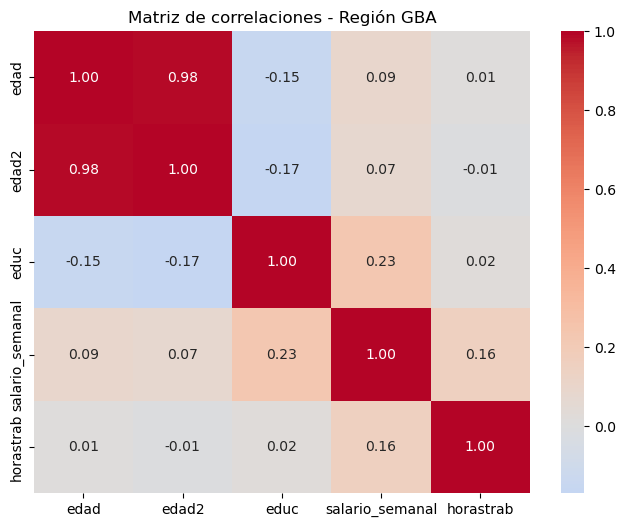

In [46]:
# Ahora sí, calculás la matriz
columnas_correlacion = ['edad', 'edad2', 'educ', 'salario_semanal', 'horastrab']
df_corr = df_gba[columnas_correlacion].dropna()
matriz_corr = df_corr.corr(method='pearson')
print(matriz_corr)


# Seleccionamos solo las variables deseadas
columnas_correlacion = ['edad', 'edad2', 'educ', 'salario_semanal', 'horastrab']

# Eliminamos filas con valores nulos en esas columnas
df_corr = df_gba[columnas_correlacion].dropna()

# Calculamos la matriz de correlaciones de Pearson
matriz_corr = df_corr.corr(method='pearson')

# Mostramos la matriz en consola
print("Matriz de correlaciones:")
print(matriz_corr)

# Visualizamos con un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de correlaciones - Región GBA')
plt.show()

#### Punto 2

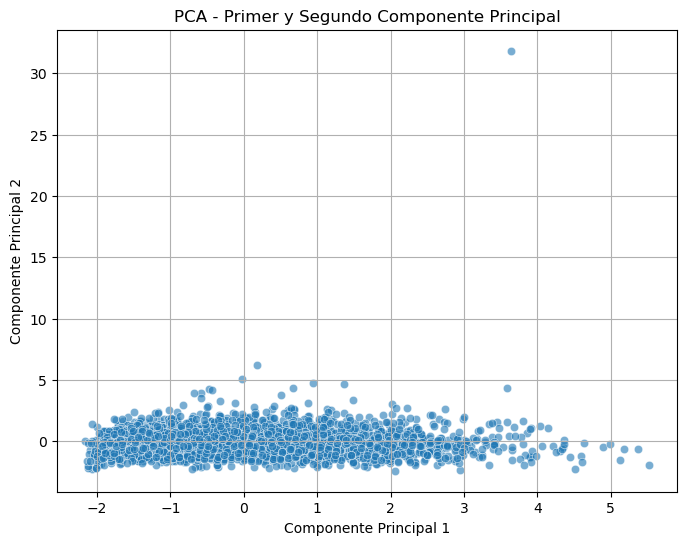

Varianza explicada por cada componente: [0.40772899 0.2577149 ]


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# Paso 1: Seleccionar las columnas y eliminar NaNs
columnas_pca = ['edad', 'edad2', 'educ', 'salario_semanal', 'horastrab']
df_pca = df_gba[columnas_pca].dropna()

# Paso 2: Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(df_pca)

# Paso 3: PCA
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_std)

# Paso 4: Crear DataFrame con los scores
df_scores = pd.DataFrame(data=componentes, columns=['PC1', 'PC2'])

# Paso 5: Graficar
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_scores, alpha=0.6)
plt.title('PCA - Primer y Segundo Componente Principal')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# Opcional: ver varianza explicada
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)

#### Punto 3

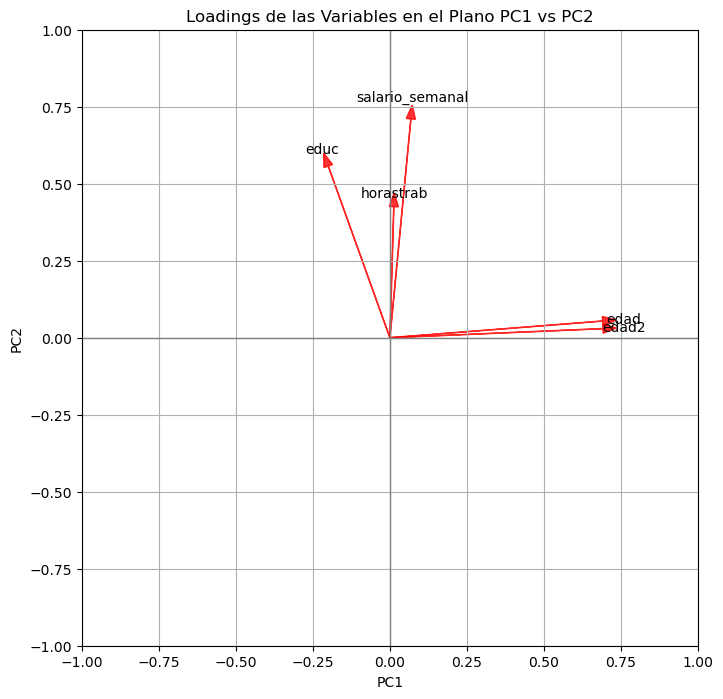

In [48]:
# Nombres de las variables
variables = ['edad', 'edad2', 'educ', 'salario_semanal', 'horastrab']

# Obtener los componentes (loadings)
loadings = pca.components_.T  # Transponer para que cada fila sea una variable

# Crear gráfico
plt.figure(figsize=(8, 8))
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)

# Dibujar flechas para cada variable
for i, var in enumerate(variables):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              color='r', alpha=0.8, head_width=0.03)
    plt.text(loadings[i, 0] * 1.1, loadings[i, 1] * 1.1, var,
             color='black', ha='center', va='center')

# Estética
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Loadings de las Variables en el Plano PC1 vs PC2')
plt.grid(True)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

#### Punto 4 

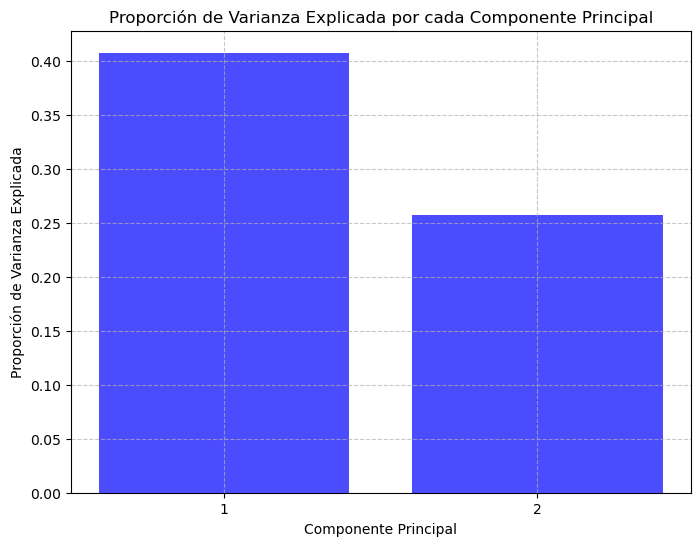

In [49]:
# Proporción de varianza explicada por cada componente
var_explicada = pca.explained_variance_ratio_

# Crear gráfico de barras
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(var_explicada) + 1), var_explicada, alpha=0.7, color='b', label="Varianza Explicada")
plt.xlabel('Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('Proporción de Varianza Explicada por cada Componente Principal')
plt.xticks(range(1, len(var_explicada) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

En la mayoría de los casos, el primer componente tendrá la mayor proporción de varianza explicada, seguido por el segundo componente, y así sucesivamente.
Si el primer o primer y segundo componentes explican una gran parte de la varianza, podrías considerar que con pocos componentes puedes captar gran parte de la variabilidad de los datos.
Si los componentes posteriores tienen una proporción pequeña, indica que esas dimensiones adicionales no aportan mucha información relevante y podrían ser descartadas para simplificar el modelo.

#### Punto 5.A









Preprocesamiento y Establecimiento de Variables

In [50]:
# Aseguramos que las variables a utilizar estén correctamente definidas
columnas_correlacion = ['edad', 'edad2', 'educ', 'salario_semanal', 'horastrab']

# Eliminamos los valores nulos y estandarizamos los datos
df_corr = df_gba[columnas_correlacion].dropna()

# Establecemos el estandarizador
scaler = StandardScaler()

# Estandarizamos las variables
df_corr_scaled = scaler.fit_transform(df_corr)

# Seleccionamos dos predictores para graficar (ejemplo: 'edad' y 'salario_semanal')
df_predictores = df_corr[['edad', 'salario_semanal']].dropna()

# Estandarizamos los predictores
df_predictores_scaled = scaler.fit_transform(df_predictores)
plt.show()

Aplicación de K-medias con Diferentes Valores de k

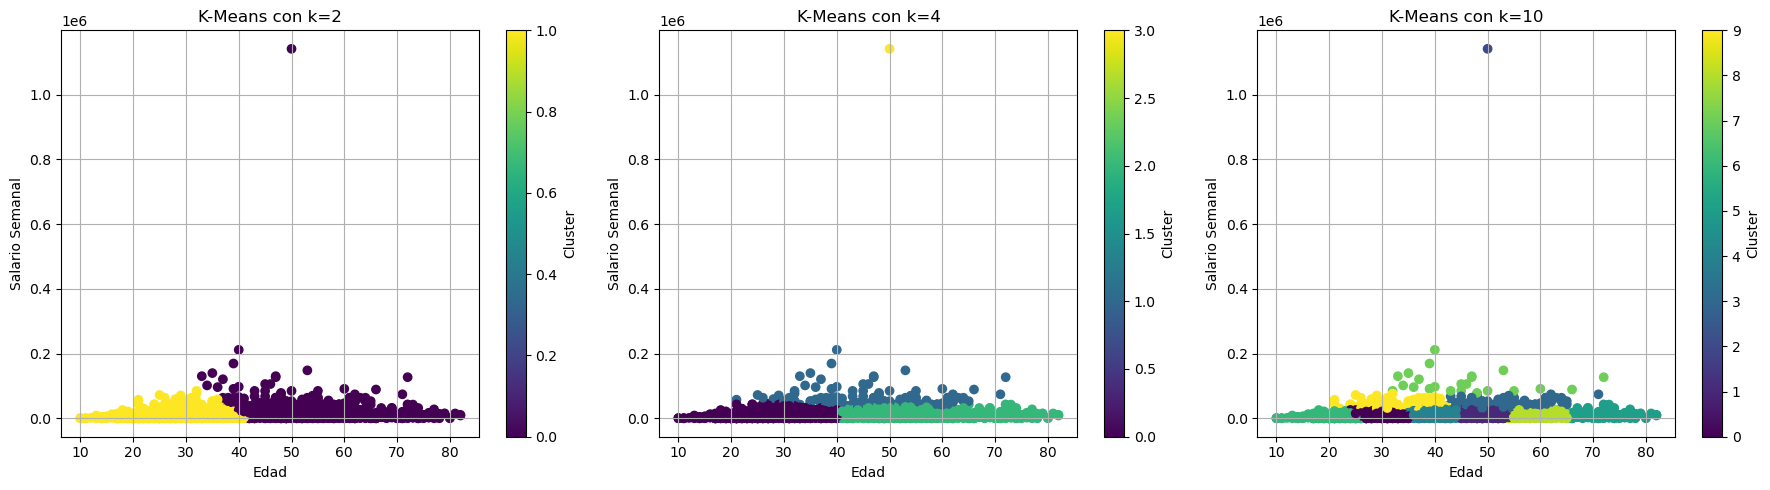

In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Definimos la lista de valores de k que queremos probar
k_values = [2, 4, 10]

# Graficamos los resultados para cada valor de k
plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values, 1):
    # Aplica el modelo K-means
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    df_predictores['Cluster'] = kmeans.fit_predict(df_predictores_scaled)
    
    plt.subplot(1, len(k_values), i)
    plt.scatter(df_predictores['edad'], df_predictores['salario_semanal'], c=df_predictores['Cluster'], cmap='viridis')
    plt.title(f'K-Means con k={k}')
    plt.xlabel('Edad')
    plt.ylabel('Salario Semanal')
    plt.colorbar(label='Cluster')
    plt.grid(True)

plt.tight_layout()
plt.show()

#### 5.B

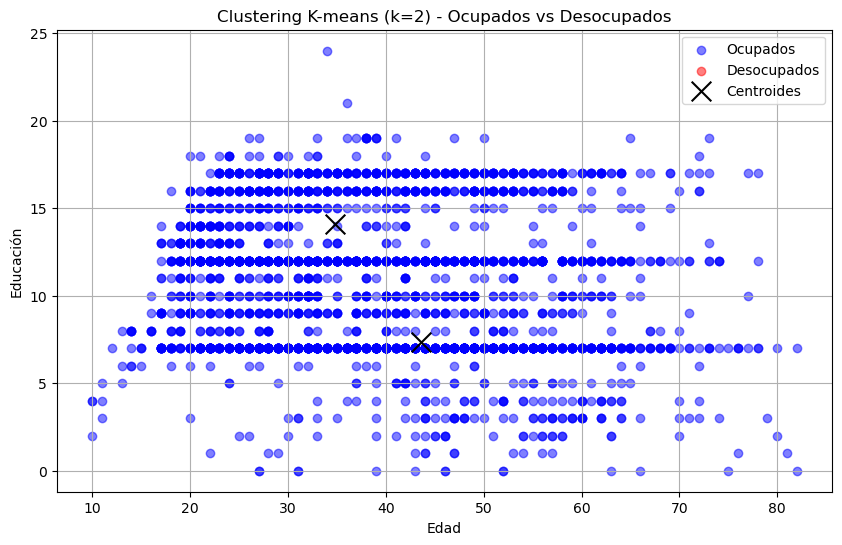

In [52]:
# Definir los predictores
predictores = ['edad', 'educ', 'salario_semanal', 'horastrab']

# Limpiar el DataFrame
df_gba_limpio = df_gba.dropna(subset=predictores + ['ESTADO'])  # eliminar nulos
df_gba_limpio = df_gba_limpio[(df_gba_limpio != float('inf')).all(axis=1)]  # eliminar infinitos

# Estandarizar los datos
scaler = StandardScaler()
df_predictores_scaled_limpio = scaler.fit_transform(df_gba_limpio[predictores])

# Aplicar K-means
k = 2
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
df_gba_limpio['Cluster'] = kmeans.fit_predict(df_predictores_scaled_limpio)

# Separar ocupados y desocupados
ocupados = df_gba_limpio[df_gba_limpio['ESTADO'] == 'Ocupado']
desocupados = df_gba_limpio[df_gba_limpio['ESTADO'] == 'Desocupado']

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(ocupados['edad'], ocupados['educ'], c='blue', label='Ocupados', alpha=0.5)
plt.scatter(desocupados['edad'], desocupados['educ'], c='red', label='Desocupados', alpha=0.5)

# Centroides (transformarlos para graficarlos en las variables originales)
centroides_escalados = kmeans.cluster_centers_
centroides = scaler.inverse_transform(centroides_escalados)
plt.scatter(centroides[:, predictores.index('edad')], centroides[:, predictores.index('educ')],
            c='black', marker='x', s=200, label='Centroides')

plt.title('Clustering K-means (k=2) - Ocupados vs Desocupados')
plt.xlabel('Edad')
plt.ylabel('Educación')
plt.legend()
plt.grid(True)
plt.show()



Se observa que los clusters generados no coinciden perfectamente con la variable real de ocupación (POCUP), ya que ambos grupos contienen tanto personas ocupadas como desocupadas.
Esto es esperable, ya que el algoritmo K-means no utiliza etiquetas (es no supervisado) y forma los grupos en base a similitudes en las variables numéricas.
Si bien puede haber cierta asociación entre edad/educación y ocupación, no es suficiente para una separación clara, lo que indica que otros factores podrían estar influyendo en la condición de actividad laboral.

#### 6.

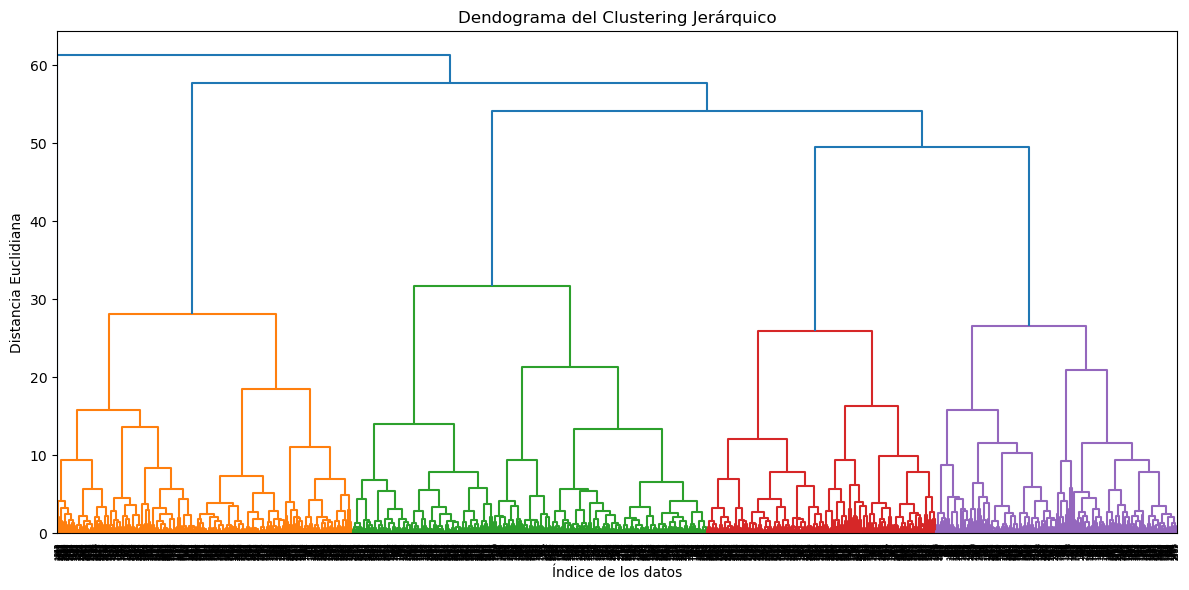

In [53]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Seleccionar las variables para el clustering
predictores = ['edad', 'educ', 'salario_semanal', 'horastrab']

# Eliminar filas con valores nulos o infinitos en el DataFrame
df_gba_limpio = df_gba[predictores].dropna()  # Elimina filas con NaN
df_gba_limpio = df_gba_limpio[(df_gba_limpio != float('inf')).all(axis=1)]  # Elimina filas con Inf

# Estandarizar los datos de los predictores
scaler = StandardScaler()
df_predictores_scaled = scaler.fit_transform(df_gba_limpio)

# Realizar el clustering jerárquico (agregativo)
plt.figure(figsize=(12, 6))  # Ajustar el tamaño de la figura para mayor espacio
dendrograma = sch.dendrogram(sch.linkage(df_predictores_scaled, method='ward'))

# Rotar las etiquetas del eje X para que no se sobrepongan
plt.xticks(rotation=90)

# Títulos y etiquetas del gráfico
plt.title('Dendograma del Clustering Jerárquico')
plt.xlabel('Índice de los datos')
plt.ylabel('Distancia Euclidiana')
plt.tight_layout()  # Ajustar el layout para que todo se vea bien
plt.show()

¿Qué es un dendograma? Un dendograma es una representación visual de un árbol jerárquico que muestra cómo los clusters se agrupan. En el dendograma, cada hoja representa un punto de datos y los nodos representan las combinaciones de puntos o clusters. La altura de los nodos indica la distancia (o disimilitud) entre los clusters que se están uniendo. Cuanto mayor sea la distancia, más disímiles son los grupos. Es una excelente herramienta para visualizar cómo se forman los clusters a medida que avanzamos en el proceso de agrupamiento.